In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('../datasets/clinic_cvc'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

../datasets/clinic_cvc\class_dict.csv
../datasets/clinic_cvc\metadata.csv
../datasets/clinic_cvc\PNG\Ground Truth\1.png
../datasets/clinic_cvc\PNG\Ground Truth\10.png
../datasets/clinic_cvc\PNG\Ground Truth\100.png
../datasets/clinic_cvc\PNG\Ground Truth\101.png
../datasets/clinic_cvc\PNG\Ground Truth\102.png
../datasets/clinic_cvc\PNG\Ground Truth\103.png
../datasets/clinic_cvc\PNG\Ground Truth\104.png
../datasets/clinic_cvc\PNG\Ground Truth\105.png
../datasets/clinic_cvc\PNG\Ground Truth\106.png
../datasets/clinic_cvc\PNG\Ground Truth\107.png
../datasets/clinic_cvc\PNG\Ground Truth\108.png
../datasets/clinic_cvc\PNG\Ground Truth\109.png
../datasets/clinic_cvc\PNG\Ground Truth\11.png
../datasets/clinic_cvc\PNG\Ground Truth\110.png
../datasets/clinic_cvc\PNG\Ground Truth\111.png
../datasets/clinic_cvc\PNG\Ground Truth\112.png
../datasets/clinic_cvc\PNG\Ground Truth\113.png
../datasets/clinic_cvc\PNG\Ground Truth\114.png
../datasets/clinic_cvc\PNG\Ground Truth\115.png
../datasets/clinic

In [2]:
import os, cv2
import numpy as np
import pandas as pd
import random, tqdm
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import albumentations as album

In [3]:
import segmentation_models_pytorch as smp

In [4]:
DATA_DIR = '../datasets/clinic_cvc'

metadata_df = pd.read_csv(os.path.join(DATA_DIR, 'metadata.csv'))
metadata_df = metadata_df[['frame_id', 'png_image_path', 'png_mask_path']]
metadata_df['png_image_path'] = metadata_df['png_image_path'].apply(lambda img_pth: os.path.join(DATA_DIR, img_pth))
metadata_df['png_mask_path'] = metadata_df['png_mask_path'].apply(lambda img_pth: os.path.join(DATA_DIR, img_pth))
# Shuffle DataFrame
metadata_df = metadata_df.sample(frac=1).reset_index(drop=True)

# Perform 90/10 split for train / val
valid_df = metadata_df.sample(frac=0.1, random_state=42)
train_df = metadata_df.drop(valid_df.index)
len(train_df), len(valid_df)

(551, 61)

In [5]:
# Normalize and validate file paths in metadata_df — drop rows with missing files
import os

# Normalize paths (fix mixed slashes, relative paths)
metadata_df['png_image_path'] = metadata_df['png_image_path'].apply(lambda p: os.path.normpath(p))
metadata_df['png_mask_path'] = metadata_df['png_mask_path'].apply(lambda p: os.path.normpath(p))

# Quick existence check and drop missing entries
exists_img = metadata_df['png_image_path'].apply(os.path.exists)
exists_mask = metadata_df['png_mask_path'].apply(os.path.exists)
valid_rows = exists_img & exists_mask

missing_count = (~valid_rows).sum()
if missing_count > 0:
    print(f"Found {missing_count} metadata rows with missing image or mask files. Dropping them.")
    # show a few missing examples for debugging
    print(metadata_df.loc[~valid_rows, ['frame_id', 'png_image_path', 'png_mask_path']].head(10).to_string(index=False))
else:
    print('All referenced image and mask files are present.')

# Keep only valid rows
metadata_df = metadata_df.loc[valid_rows].reset_index(drop=True)
print(f"Metadata rows after drop: {len(metadata_df)}")

Found 202 metadata rows with missing image or mask files. Dropping them.
 frame_id                              png_image_path                                   png_mask_path
      481 ..\datasets\clinic_cvc\PNG\Original\481.png ..\datasets\clinic_cvc\PNG\Ground Truth\481.png
      534 ..\datasets\clinic_cvc\PNG\Original\534.png ..\datasets\clinic_cvc\PNG\Ground Truth\534.png
       65  ..\datasets\clinic_cvc\PNG\Original\65.png  ..\datasets\clinic_cvc\PNG\Ground Truth\65.png
      489 ..\datasets\clinic_cvc\PNG\Original\489.png ..\datasets\clinic_cvc\PNG\Ground Truth\489.png
      498 ..\datasets\clinic_cvc\PNG\Original\498.png ..\datasets\clinic_cvc\PNG\Ground Truth\498.png
      563 ..\datasets\clinic_cvc\PNG\Original\563.png ..\datasets\clinic_cvc\PNG\Ground Truth\563.png
       71  ..\datasets\clinic_cvc\PNG\Original\71.png  ..\datasets\clinic_cvc\PNG\Ground Truth\71.png
        7   ..\datasets\clinic_cvc\PNG\Original\7.png   ..\datasets\clinic_cvc\PNG\Ground Truth\7.png
      553

In [6]:
# metadata_df already loaded and validated in an earlier cell.
# Re-use the validated `metadata_df` to create train/validation splits (do not re-read file here).
valid_df = metadata_df.sample(frac=0.1, random_state=42)
train_df = metadata_df.drop(valid_df.index).reset_index(drop=True)
len(train_df), len(valid_df)

(369, 41)

In [7]:
class_dict = pd.read_csv(os.path.join(DATA_DIR, 'class_dict.csv'))
# Get class names
class_names = class_dict['class_names'].tolist()
# Get class RGB values
class_rgb_values = class_dict[['r','g','b']].values.tolist()

print('All dataset classes and their corresponding RGB values in labels:')
print('Class Names: ', class_names)
print('Class RGB values: ', class_rgb_values)

All dataset classes and their corresponding RGB values in labels:
Class Names:  ['background', 'polyp']
Class RGB values:  [[0, 0, 0], [255, 255, 255]]


In [8]:
# Useful to shortlist specific classes in datasets with large number of classes
select_classes = ['background', 'polyp']

# Get RGB values of required classes
select_class_indices = [class_names.index(cls.lower()) for cls in select_classes]
select_class_rgb_values =  np.array(class_rgb_values)[select_class_indices]

print('Selected classes and their corresponding RGB values in labels:')
print('Class Names: ', class_names)
print('Class RGB values: ', class_rgb_values)

Selected classes and their corresponding RGB values in labels:
Class Names:  ['background', 'polyp']
Class RGB values:  [[0, 0, 0], [255, 255, 255]]


In [9]:
# helper function for data visualization
def visualize(**images):
    """
    Plot images in one row
    """
    n_images = len(images)
    plt.figure(figsize=(20,8))
    for idx, (name, image) in enumerate(images.items()):
        plt.subplot(1, n_images, idx + 1)
        plt.xticks([]); 
        plt.yticks([])
        # get title from the parameter names
        plt.title(name.replace('_',' ').title(), fontsize=20)
        plt.imshow(image)
    plt.show()

# Perform one hot encoding on label
def one_hot_encode(label, label_values):
    """
    Convert a segmentation image label array to one-hot format
    by replacing each pixel value with a vector of length num_classes
    # Arguments
        label: The 2D array segmentation image label
        label_values
        
    # Returns
        A 2D array with the same width and hieght as the input, but
        with a depth size of num_classes
    """
    semantic_map = []
    for colour in label_values:
        equality = np.equal(label, colour)
        class_map = np.all(equality, axis = -1)
        semantic_map.append(class_map)
    semantic_map = np.stack(semantic_map, axis=-1)

    return semantic_map
    
# Perform reverse one-hot-encoding on labels / preds
def reverse_one_hot(image):
    """
    Transform a 2D array in one-hot format (depth is num_classes),
    to a 2D array with only 1 channel, where each pixel value is
    the classified class key.
    # Arguments
        image: The one-hot format image 
        
    # Returns
        A 2D array with the same width and hieght as the input, but
        with a depth size of 1, where each pixel value is the classified 
        class key.
    """
    x = np.argmax(image, axis = -1)
    return x

# Perform colour coding on the reverse-one-hot outputs
def colour_code_segmentation(image, label_values):
    """
    Given a 1-channel array of class keys, colour code the segmentation results.
    # Arguments
        image: single channel array where each value represents the class key.
        label_values

    # Returns
        Colour coded image for segmentation visualization
    """
    colour_codes = np.array(label_values)
    x = colour_codes[image.astype(int)]

    return x

In [10]:
class EndoscopyDataset(torch.utils.data.Dataset):

    """CVC-ClinicDB Endoscopic Colonoscopy Dataset. Read images, apply augmentation and preprocessing transformations.
    
    Args:
        df (str): DataFrame containing images / labels paths
        class_rgb_values (list): RGB values of select classes to extract from segmentation mask
        augmentation (albumentations.Compose): data transfromation pipeline 
            (e.g. flip, scale, etc.)
        preprocessing (albumentations.Compose): data preprocessing 
            (e.g. noralization, shape manipulation, etc.)
    
    """
    def __init__(
            self, 
            df,
            class_rgb_values=None, 
            augmentation=None, 
            preprocessing=None,
    ):
        self.image_paths = df['png_image_path'].tolist()
        self.mask_paths = df['png_mask_path'].tolist()
        
        self.class_rgb_values = class_rgb_values
        self.augmentation = augmentation
        self.preprocessing = preprocessing
    
    def __getitem__(self, i):
        
        # read images and masks with defensive checks
        img_path = self.image_paths[i]
        mask_path = self.mask_paths[i]

        image = cv2.imread(img_path)
        if image is None:
            # provide a helpful error message and list nearby files for debugging
            nearby = []
            try:
                dirname = os.path.dirname(img_path)
                nearby = os.listdir(dirname)[:10]
            except Exception:
                pass
            raise FileNotFoundError(f"Unable to read image file: {img_path}. Nearby files: {nearby}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path)
        if mask is None:
            nearby = []
            try:
                dirname = os.path.dirname(mask_path)
                nearby = os.listdir(dirname)[:10]
            except Exception:
                pass
            raise FileNotFoundError(f"Unable to read mask file: {mask_path}. Nearby files: {nearby}")
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        
        # one-hot-encode the mask
        mask = one_hot_encode(mask, self.class_rgb_values).astype('float')
        
        # apply augmentations
        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
        
        # apply preprocessing
        if self.preprocessing:
            sample = self.preprocessing(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
            
        return image, mask
        
    def __len__(self):
        # return length of 
        return len(self.image_paths)

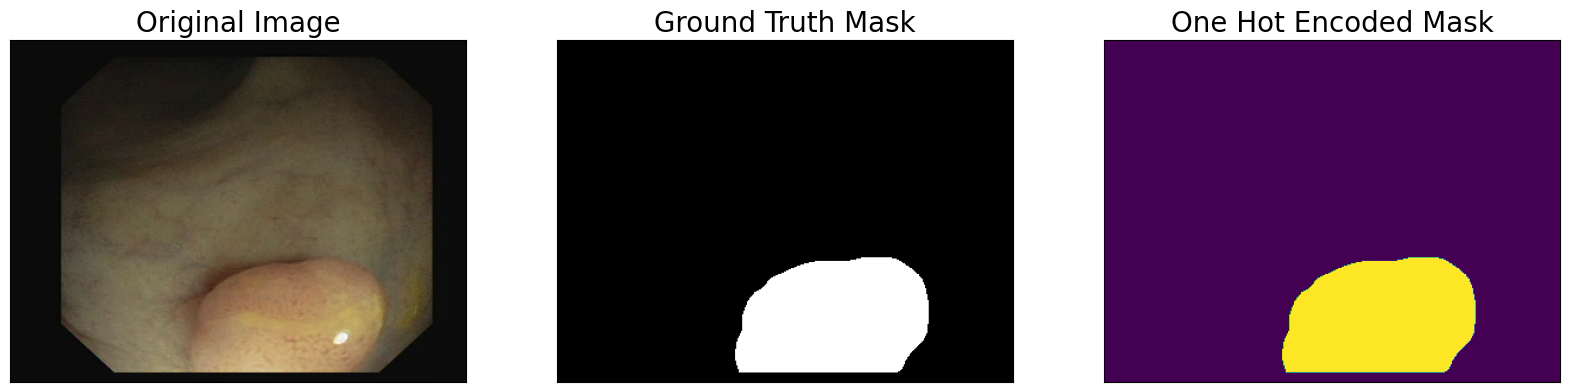

In [11]:
dataset = EndoscopyDataset(train_df, class_rgb_values=select_class_rgb_values)
random_idx = random.randint(0, len(dataset)-1)
image, mask = dataset[2]

visualize(
    original_image = image,
    ground_truth_mask = colour_code_segmentation(reverse_one_hot(mask), select_class_rgb_values),
    one_hot_encoded_mask = reverse_one_hot(mask)
)

In [12]:
def get_training_augmentation():
    train_transform = [
        album.HorizontalFlip(p=0.5),
    ]
    return album.Compose(train_transform)


def get_validation_augmentation():
    # Add sufficient padding to ensure image is divisible by 32
    test_transform = [
        album.PadIfNeeded(min_height=288, min_width=384, always_apply=True, border_mode=0),
    ]
    return album.Compose(test_transform)


def to_tensor(x, **kwargs):
    return x.transpose(2, 0, 1).astype('float32')


def get_preprocessing(preprocessing_fn=None):
    """Construct preprocessing transform    
    Args:
        preprocessing_fn (callable): data normalization function 
            (can be specific for each pretrained neural network)
    Return:
        transform: albumentations.Compose
    """   
    _transform = []
    if preprocessing_fn:
        _transform.append(album.Lambda(image=preprocessing_fn))
    _transform.append(album.Lambda(image=to_tensor, mask=to_tensor))
        
    return album.Compose(_transform)

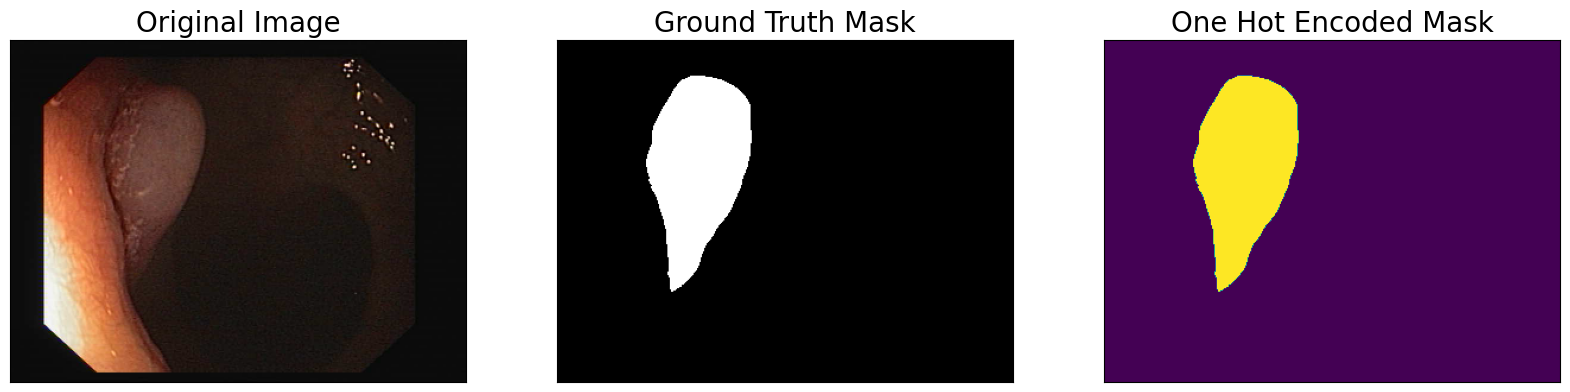

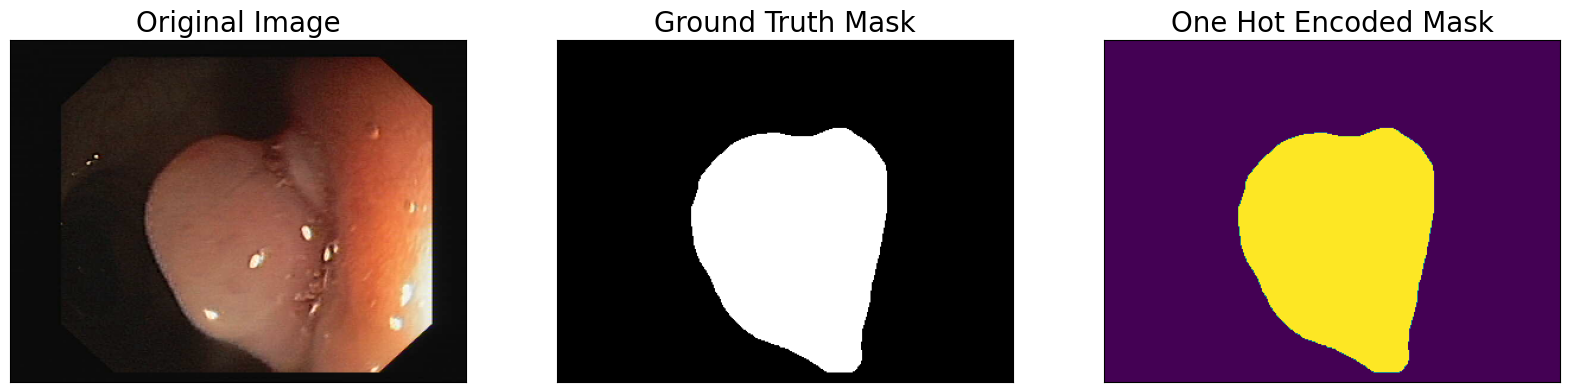

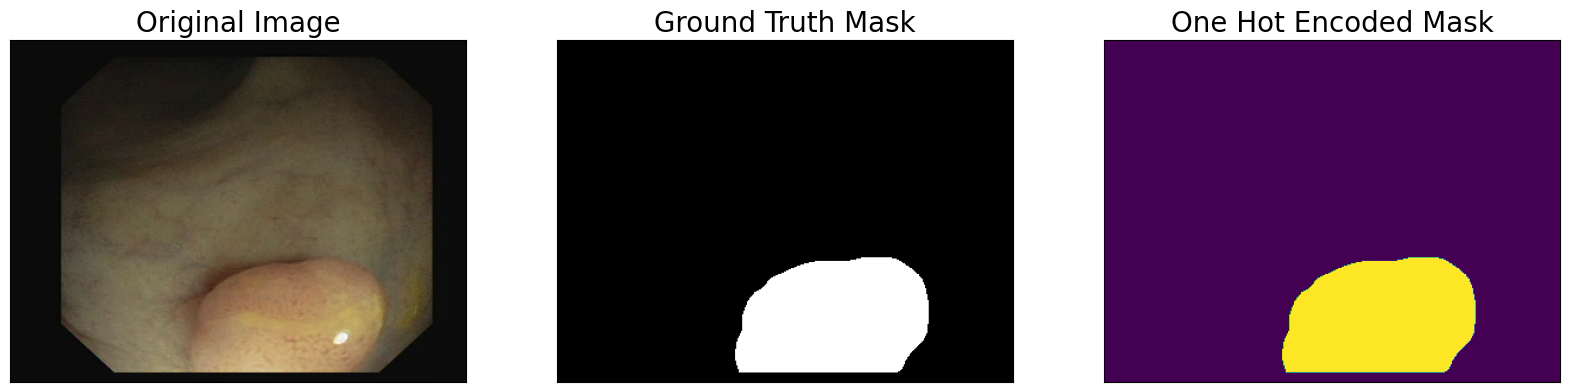

In [13]:
augmented_dataset = EndoscopyDataset(
    train_df, 
    augmentation=get_training_augmentation(),
    class_rgb_values=select_class_rgb_values,
)

random_idx = random.randint(0, len(augmented_dataset)-1)

# Different augmentations on image/mask pairs
for idx in range(3):
    image, mask = augmented_dataset[idx]
    visualize(
        original_image = image,
        ground_truth_mask = colour_code_segmentation(reverse_one_hot(mask), select_class_rgb_values),
        one_hot_encoded_mask = reverse_one_hot(mask)
    )

In [14]:
ENCODER = 'resnet50'
ENCODER_WEIGHTS = 'imagenet'
CLASSES = select_classes
ACTIVATION = 'sigmoid' # could be None for logits or 'softmax2d' for multiclass segmentation

# create segmentation model with pretrained encoder
model = smp.DeepLabV3Plus(
    encoder_name=ENCODER, 
    encoder_weights=ENCODER_WEIGHTS, 
    classes=len(CLASSES), 
    activation=ACTIVATION,
)

preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER, ENCODER_WEIGHTS)

In [26]:
# Get train and val dataset instances
train_dataset = EndoscopyDataset(
    train_df, 
    augmentation=get_training_augmentation(),
    preprocessing=get_preprocessing(preprocessing_fn),
    class_rgb_values=select_class_rgb_values,
)

valid_dataset = EndoscopyDataset(
    valid_df, 
    augmentation=get_validation_augmentation(), 
    preprocessing=get_preprocessing(preprocessing_fn),
    class_rgb_values=select_class_rgb_values,
)

# Get train and val data loaders
# Use num_workers=0 for notebook/Windows to avoid worker spawn/hang issues
# Use drop_last=True for the training loader to avoid batches of size 1 (BatchNorm requires >1 during training)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0, drop_last=True)
valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False, num_workers=0)


In [27]:
import segmentation_models_pytorch.utils
# Set flag to train the model or not. If set to 'False', only prediction is performed (using an older model checkpoint)
TRAINING = True

# Set num of epochs
EPOCHS = 20

# Set device: `cuda` or `cpu`
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# define loss function
loss = smp.utils.losses.DiceLoss()

# define metrics
metrics = [
    smp.utils.metrics.IoU(threshold=0.5),
]

# define optimizer
optimizer = torch.optim.Adam([ 
    dict(params=model.parameters(), lr=0.0001),
])

# define learning rate scheduler (not used in this NB)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=1, T_mult=2, eta_min=5e-5,
)

# load best saved model checkpoint from previous commit (if present)
if os.path.exists('/polyp-segmentation-in-colonoscopy-frames-deeplab/best_model.pth'):
    model = torch.load('/polyp-segmentation-in-colonoscopy-frames-deeplab/best_model.pth', map_location=DEVICE)

In [28]:
train_epoch = smp.utils.train.TrainEpoch(
    model, 
    loss=loss, 
    metrics=metrics, 
    optimizer=optimizer,
    device=DEVICE,
    verbose=True,
)

valid_epoch = smp.utils.train.ValidEpoch(
    model, 
    loss=loss, 
    metrics=metrics, 
    device=DEVICE,
    verbose=True,
)

In [29]:
# Diagnostic cell: check DataLoader & dataset speed (recreates loader with num_workers=0)
import time, traceback
print('DEVICE =', DEVICE)
print('len(train_dataset)=', len(train_dataset), 'len(valid_dataset)=', len(valid_dataset))
try:
    from torch.utils.data import DataLoader as _DL
    # recreate loaders with num_workers=0 to avoid worker hangs in notebooks/Windows
    test_train_loader = _DL(train_dataset, batch_size=16, shuffle=True, num_workers=0)
    t0 = time.time()
    batch = next(iter(test_train_loader))
    t1 = time.time()
    print(f'Fetched one train batch in {t1-t0:.3f}s')
    if isinstance(batch, (list, tuple)):
        x, y = batch
        print('x type/shape:', type(x), getattr(x, 'shape', None))
        print('y type/shape:', type(y), getattr(y, 'shape', None))
    else:
        print('Batch object:', type(batch))
except Exception as e:
    print('Error when fetching a batch:')
    traceback.print_exc()

print('\nSuggestion: If this hangs or errors, set DataLoader(num_workers=0) and check dataset.__getitem__ (cv2.imread, albumentations).')

DEVICE = cpu
len(train_dataset)= 369 len(valid_dataset)= 41
Fetched one train batch in 0.219s
x type/shape: <class 'torch.Tensor'> torch.Size([16, 3, 288, 384])
y type/shape: <class 'torch.Tensor'> torch.Size([16, 2, 288, 384])

Suggestion: If this hangs or errors, set DataLoader(num_workers=0) and check dataset.__getitem__ (cv2.imread, albumentations).
Fetched one train batch in 0.219s
x type/shape: <class 'torch.Tensor'> torch.Size([16, 3, 288, 384])
y type/shape: <class 'torch.Tensor'> torch.Size([16, 2, 288, 384])

Suggestion: If this hangs or errors, set DataLoader(num_workers=0) and check dataset.__getitem__ (cv2.imread, albumentations).


In [30]:
# Quick dry-run: do forward pass on a few batches to catch errors before full training
import time, traceback
import torch, numpy as np

print('DEVICE =', DEVICE)
model = model.to(DEVICE)
print('Model moved to', DEVICE)

max_checks = 5
checked = 0

for batch_idx, batch in enumerate(train_loader):
    try:
        # Expecting batch to be (x, y)
        if isinstance(batch, (list, tuple)) and len(batch) >= 2:
            x, y = batch[0], batch[1]
        else:
            # unexpected format
            print(f'Unexpected batch format at index {batch_idx}:', type(batch))
            x = batch
            raise RuntimeError('Batch format unexpected')

        # convert numpy -> torch if needed
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        if isinstance(y, np.ndarray):
            y = torch.from_numpy(y)

        print(f'Batch {batch_idx}: x type {type(x)}, shape {getattr(x, "shape", None)}, dtype {getattr(x, "dtype", None)}')
        print(f'            y type {type(y)}, shape {getattr(y, "shape", None)}, dtype {getattr(y, "dtype", None)}')

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        t0 = time.time()
        with torch.no_grad():
            out = model(x)
        t1 = time.time()
        print(f'Forward OK for batch {batch_idx} in {t1-t0:.3f}s; out shape: {getattr(out, "shape", None)}')

        checked += 1
        if checked >= max_checks:
            break

    except Exception:
        print(f'Error during dry-run at batch {batch_idx}:')
        traceback.print_exc()
        raise

print('Dry-run completed for', checked, 'batches')

DEVICE = cpu
Model moved to cpu
Batch 0: x type <class 'torch.Tensor'>, shape torch.Size([16, 3, 288, 384]), dtype torch.float32
            y type <class 'torch.Tensor'>, shape torch.Size([16, 2, 288, 384]), dtype torch.float32
Batch 0: x type <class 'torch.Tensor'>, shape torch.Size([16, 3, 288, 384]), dtype torch.float32
            y type <class 'torch.Tensor'>, shape torch.Size([16, 2, 288, 384]), dtype torch.float32
Forward OK for batch 0 in 2.856s; out shape: torch.Size([16, 2, 288, 384])
Forward OK for batch 0 in 2.856s; out shape: torch.Size([16, 2, 288, 384])
Batch 1: x type <class 'torch.Tensor'>, shape torch.Size([16, 3, 288, 384]), dtype torch.float32
            y type <class 'torch.Tensor'>, shape torch.Size([16, 2, 288, 384]), dtype torch.float32
Batch 1: x type <class 'torch.Tensor'>, shape torch.Size([16, 3, 288, 384]), dtype torch.float32
            y type <class 'torch.Tensor'>, shape torch.Size([16, 2, 288, 384]), dtype torch.float32
Forward OK for batch 1 in 3.06

In [31]:
%%time

# Ensure model is on the right device before training
model = model.to(DEVICE)
print('Training on device:', DEVICE)

if TRAINING:

    best_iou_score = 0.0
    train_logs_list, valid_logs_list = [], []

    try:
        for i in range(0, EPOCHS):

            # Perform training & validation
            print('\nEpoch: {}'.format(i))
            train_logs = train_epoch.run(train_loader)
            valid_logs = valid_epoch.run(valid_loader)
            train_logs_list.append(train_logs)
            valid_logs_list.append(valid_logs)

            # Save model if a better val IoU score is obtained
            if best_iou_score < valid_logs['iou_score']:
                best_iou_score = valid_logs['iou_score']
                torch.save(model, './best_model.pth')
                print('Model saved!')
    except Exception as e:
        import traceback
        print('Error during training loop:')
        traceback.print_exc()
        raise


Training on device: cpu

Epoch: 0
valid: 100%|██████████| 3/3 [00:06<00:00,  2.20s/it, dice_loss - 0.1881, iou_score - 0.9404]
Model saved!

Epoch: 1
train:   0%|          | 0/23 [00:00<?, ?it/s]
Model saved!

Epoch: 1
valid: 100%|██████████| 3/3 [00:07<00:00,  2.46s/it, dice_loss - 0.1333, iou_score - 0.9659]
Model saved!

Epoch: 2
train:   0%|          | 0/23 [00:00<?, ?it/s]
Model saved!

Epoch: 2
valid: 100%|██████████| 3/3 [00:06<00:00,  2.09s/it, dice_loss - 0.1119, iou_score - 0.971] 
Model saved!

Epoch: 3
train:   0%|          | 0/23 [00:00<?, ?it/s]
Model saved!

Epoch: 3
valid: 100%|██████████| 3/3 [00:06<00:00,  2.07s/it, dice_loss - 0.09772, iou_score - 0.9736]
Model saved!

Epoch: 4
train:   0%|          | 0/23 [00:00<?, ?it/s]
Model saved!

Epoch: 4
valid: 100%|██████████| 3/3 [00:06<00:00,  2.07s/it, dice_loss - 0.08543, iou_score - 0.9719]

Epoch: 5
valid: 100%|██████████| 3/3 [00:06<00:00,  2.07s/it, dice_loss - 0.08543, iou_score - 0.9719]

Epoch: 5
valid: 100%|█████

In [32]:
# load best saved model checkpoint from the current run
if os.path.exists('./best_model.pth'):
    best_model = torch.load('./best_model.pth', map_location=DEVICE)
    print('Loaded UNet model from this run.')

# load best saved model checkpoint from previous commit (if present)
elif os.path.exists('/polyp-segmentation-in-colonoscopy-frames-deeplab/best_model.pth'):
    best_model = torch.load('/polyp-segmentation-in-colonoscopy-frames-deeplab/best_model.pth', map_location=DEVICE)
    print('Loaded UNet model from a previous commit.')

Loaded UNet model from this run.


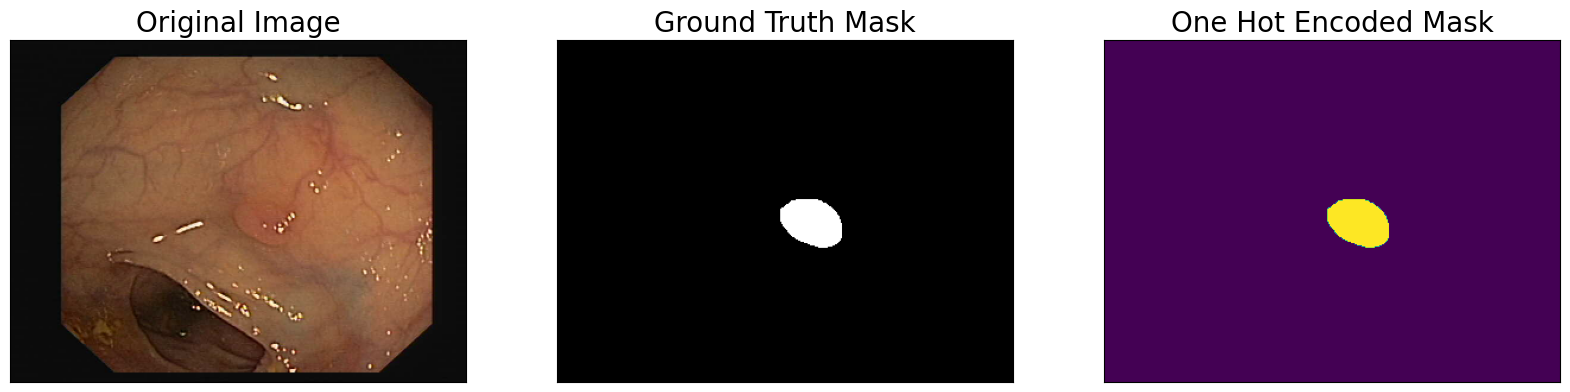

In [33]:
# create test dataloader to be used with UNet model (with preprocessing operation: to_tensor(...))
test_dataset = EndoscopyDataset(
    valid_df, 
    augmentation=get_validation_augmentation(), 
    preprocessing=get_preprocessing(preprocessing_fn),
    class_rgb_values=select_class_rgb_values,
)

test_dataloader = DataLoader(test_dataset)

# test dataset for visualization (without preprocessing augmentations & transformations)
test_dataset_vis = EndoscopyDataset(
    valid_df,
    class_rgb_values=select_class_rgb_values,
)

# get a random test image/mask index
random_idx = random.randint(0, len(test_dataset_vis)-1)
image, mask = test_dataset_vis[random_idx]

visualize(
    original_image = image,
    ground_truth_mask = colour_code_segmentation(reverse_one_hot(mask), select_class_rgb_values),
    one_hot_encoded_mask = reverse_one_hot(mask)
)

# Notice the images / masks are 1536*1536 because of 18px padding on all sides. 
# This is to ensure the input image dimensions to UNet model are a multiple of 2 (to account for pooling & transpose conv. operations).

In [34]:
# Center crop padded image / mask to original image dims
def crop_image(image, true_dimensions):
    return album.CenterCrop(p=1, height=true_dimensions[0], width=true_dimensions[1])(image=image)

In [35]:
sample_preds_folder = 'sample_predictions/'
if not os.path.exists(sample_preds_folder):
    os.makedirs(sample_preds_folder)

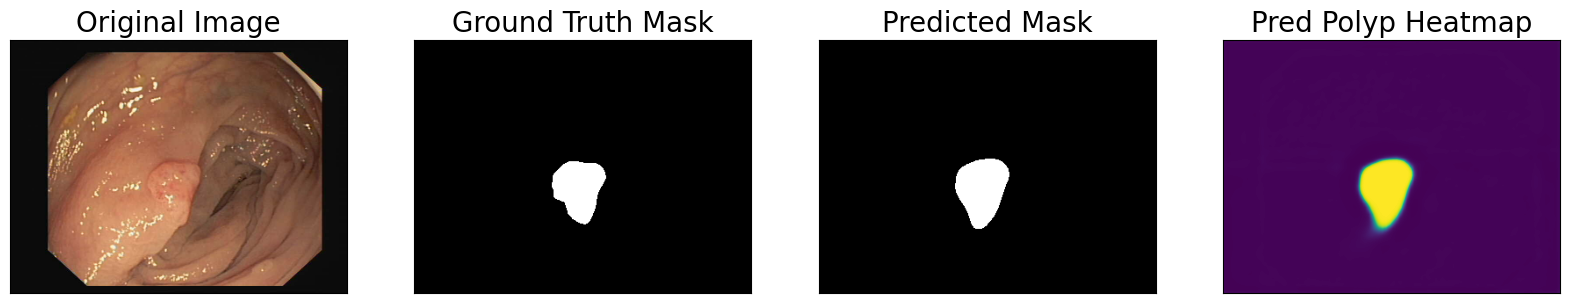

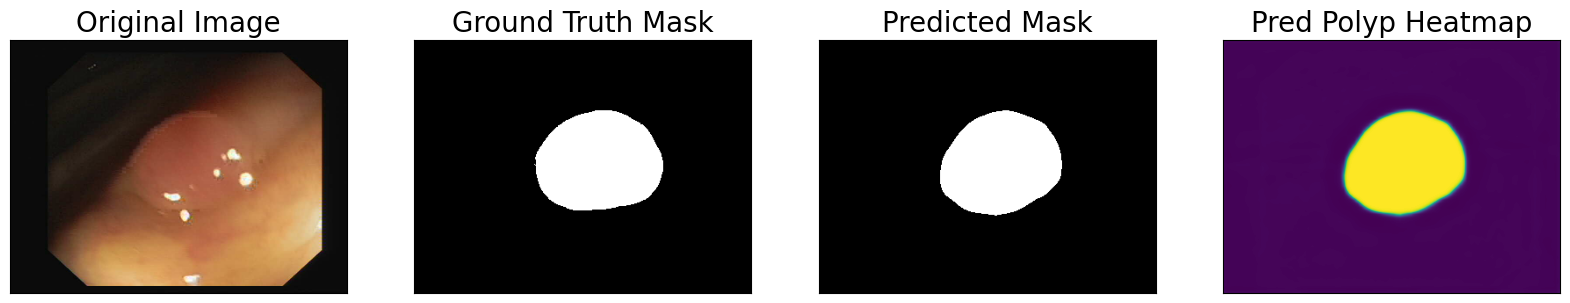

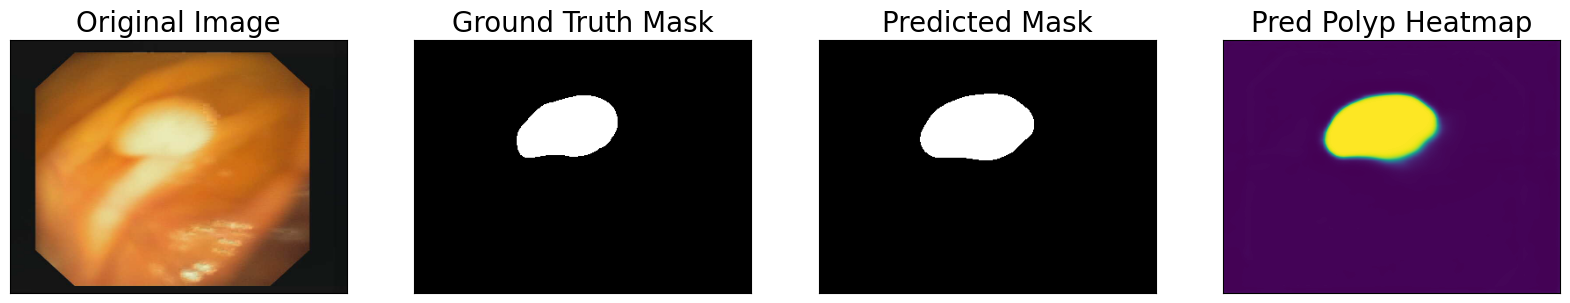

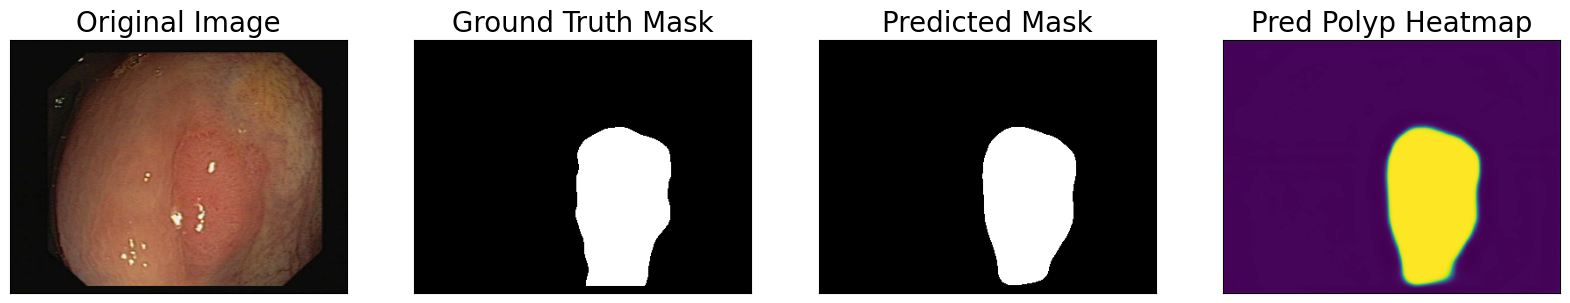

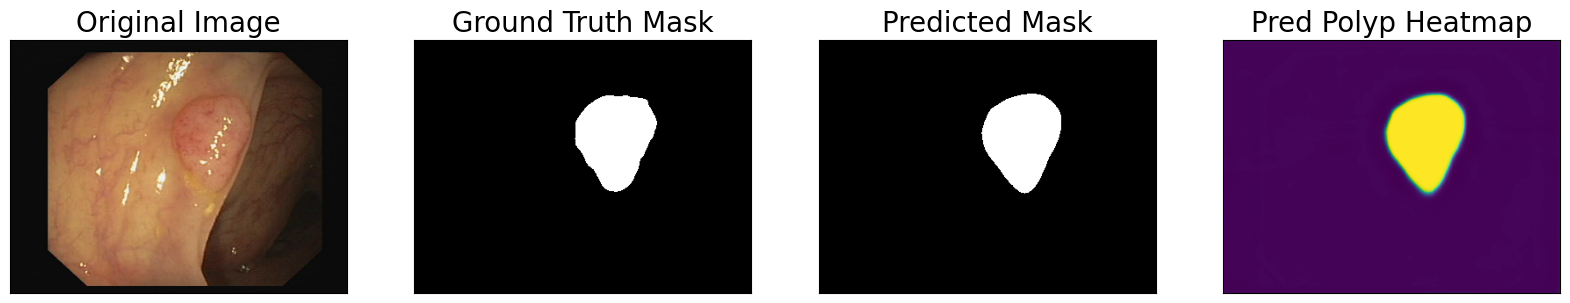

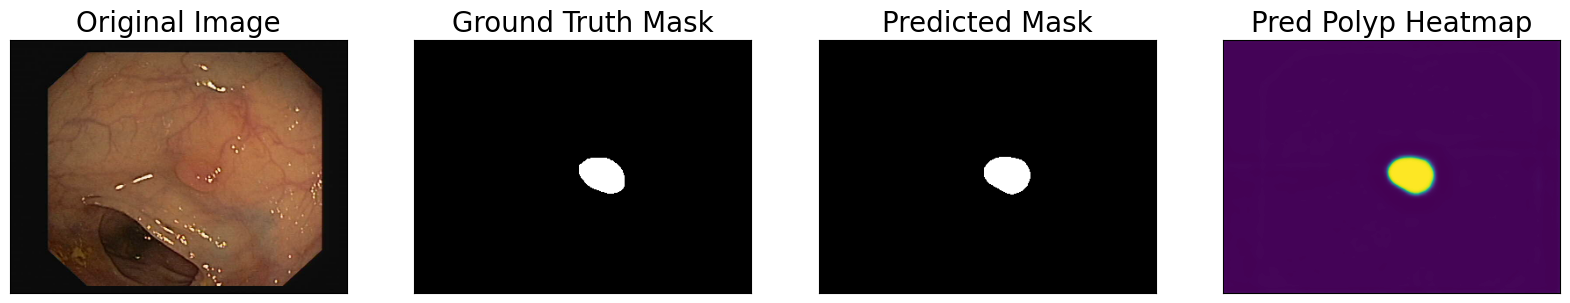

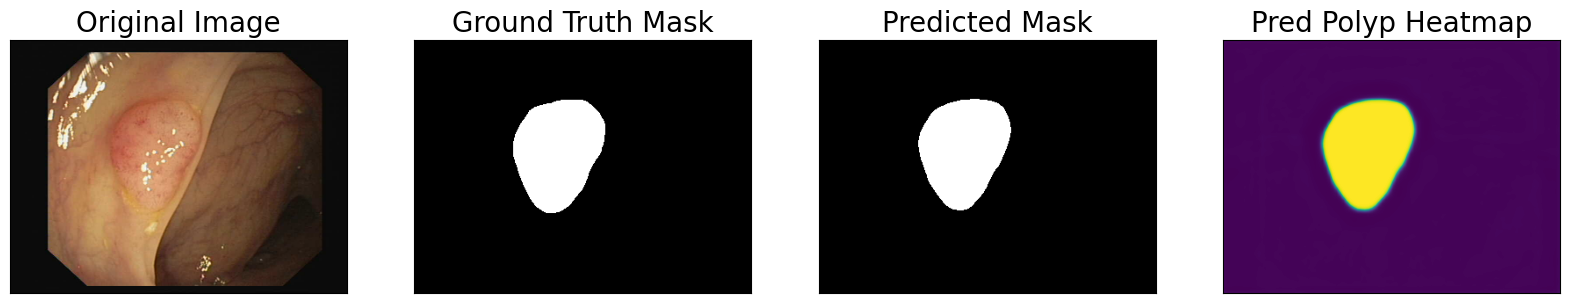

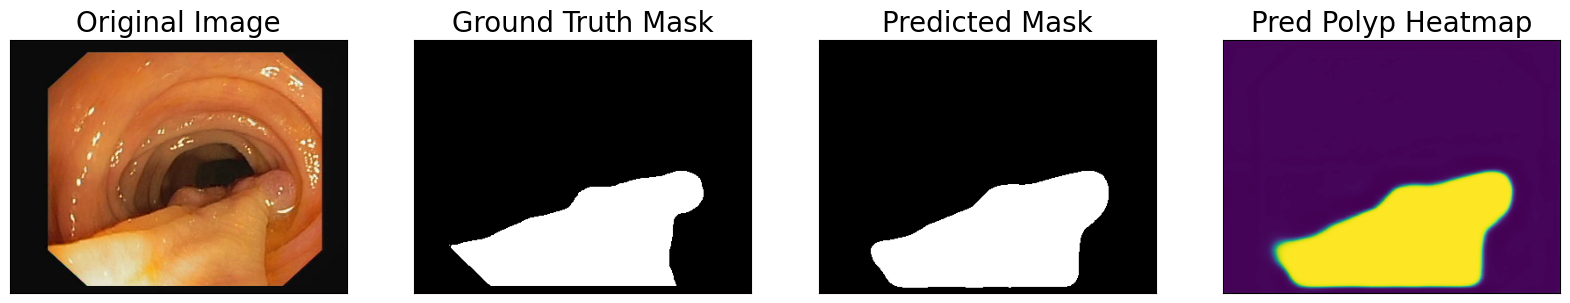

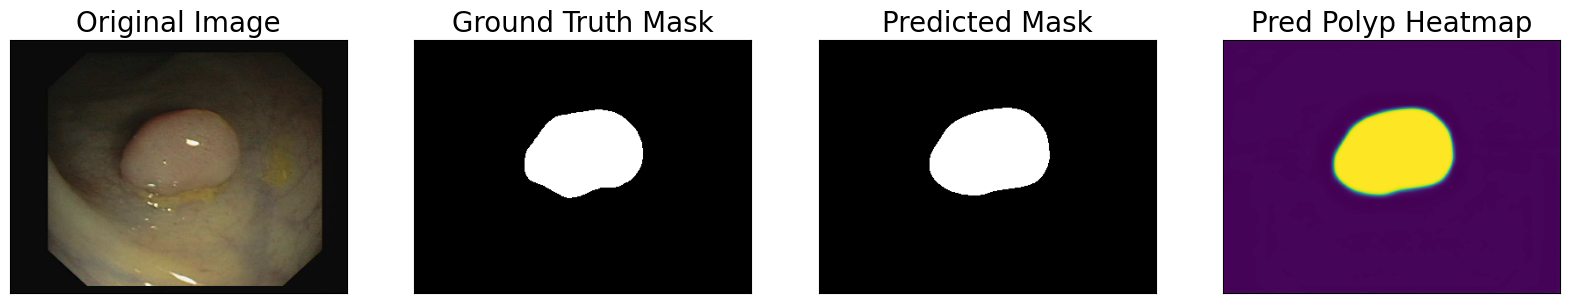

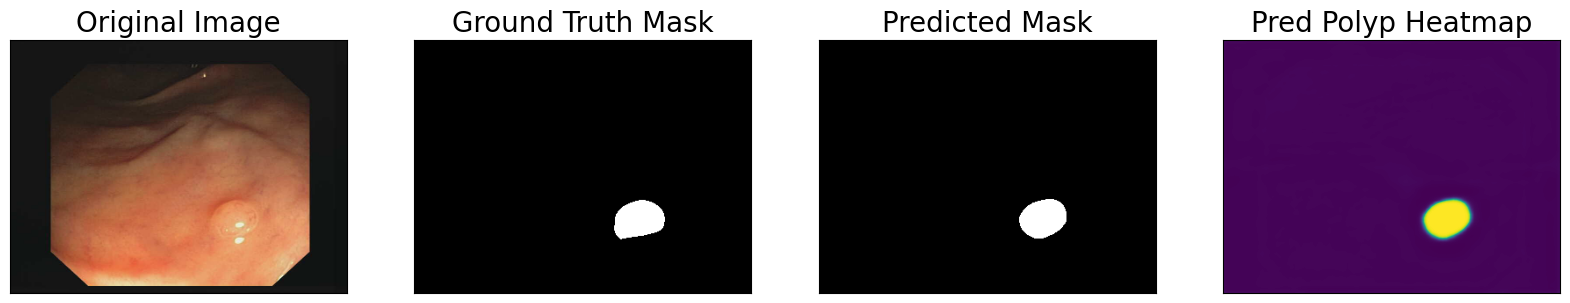

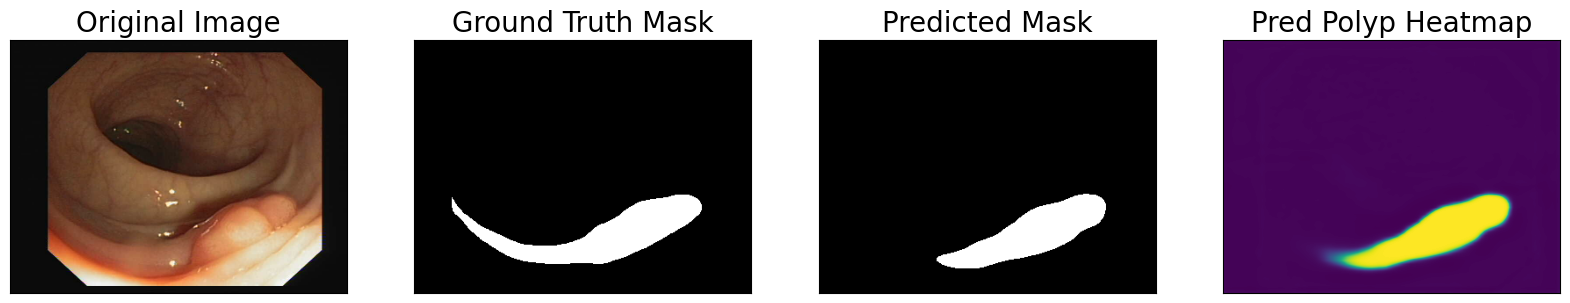

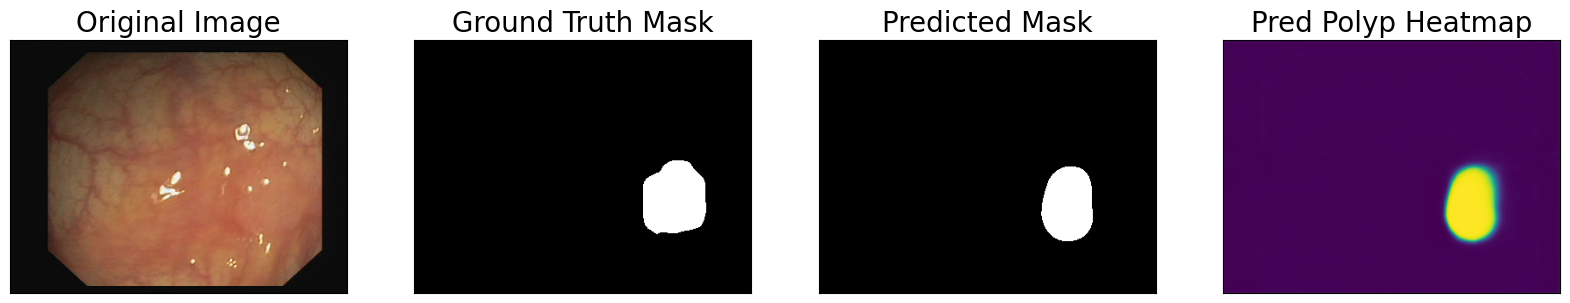

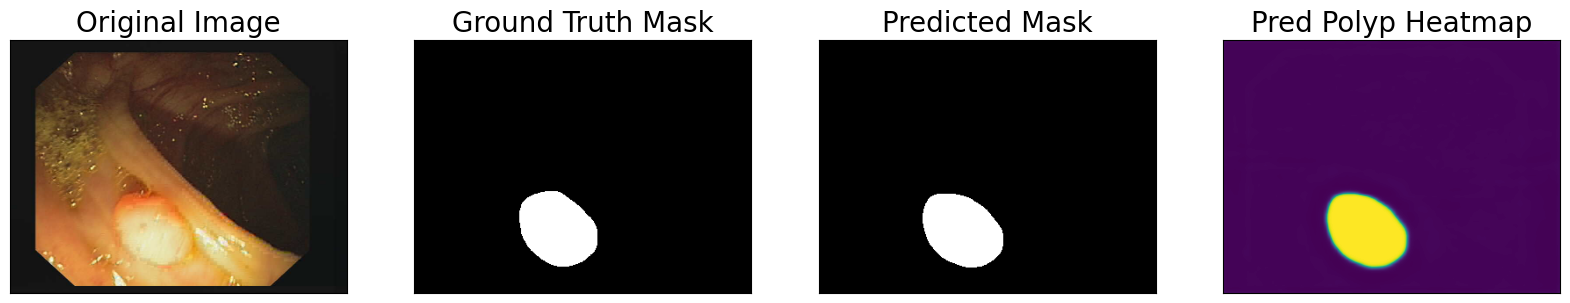

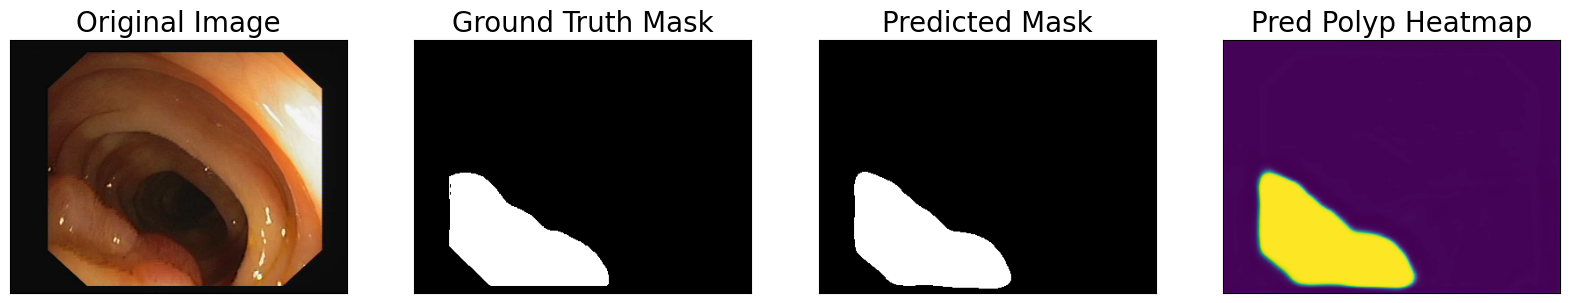

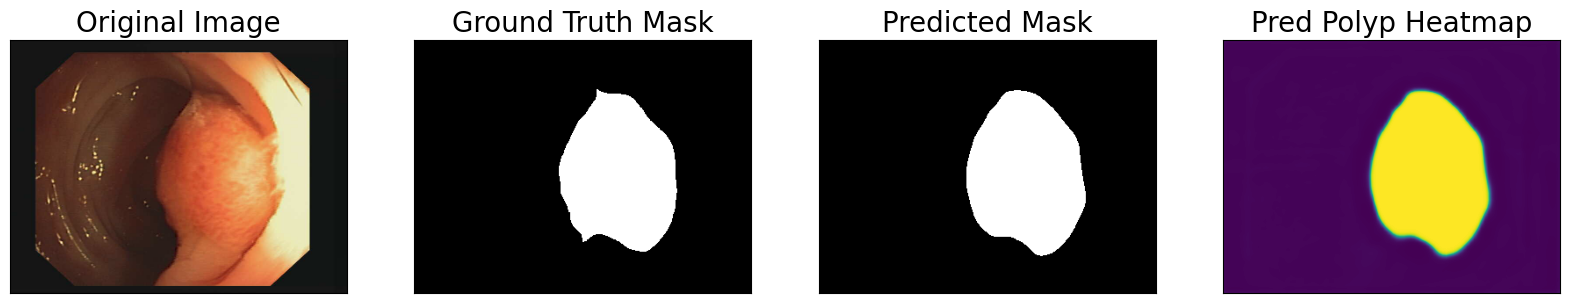

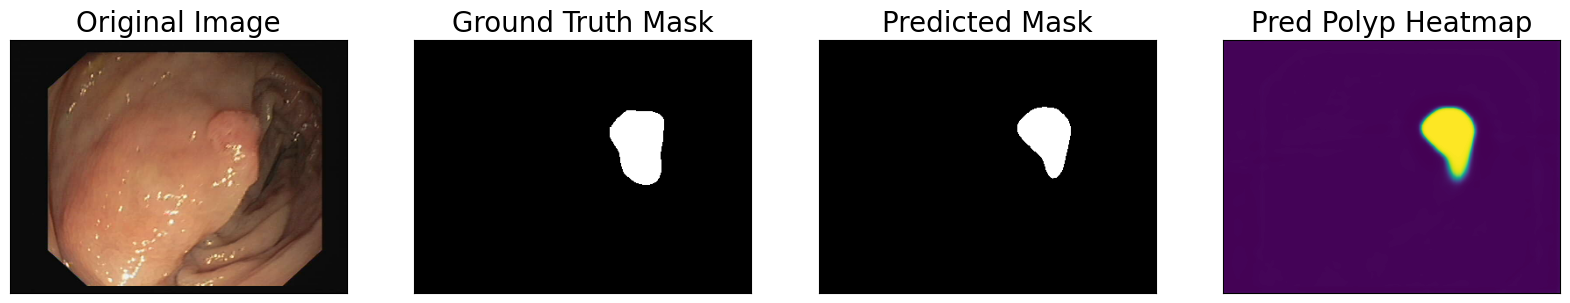

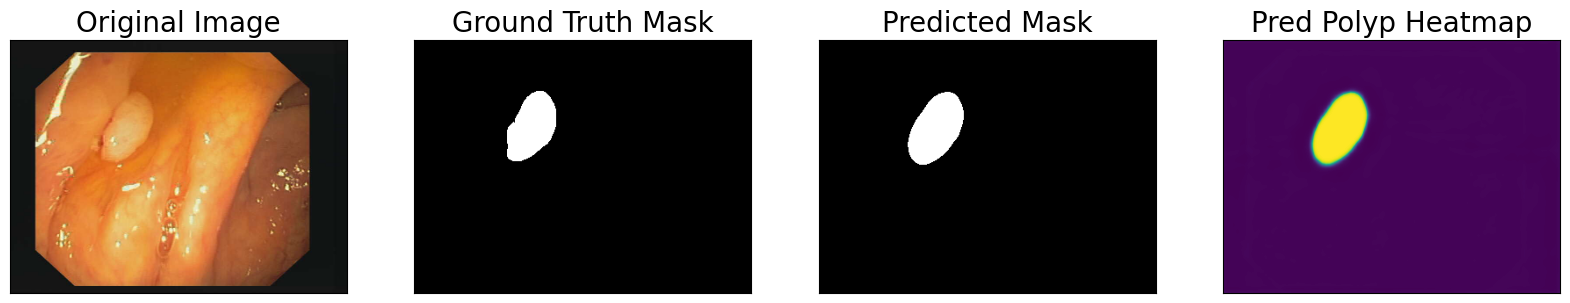

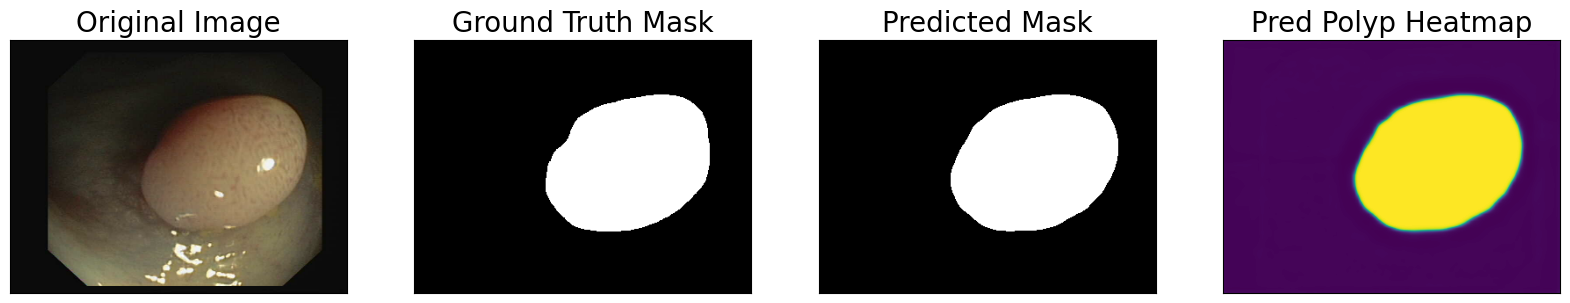

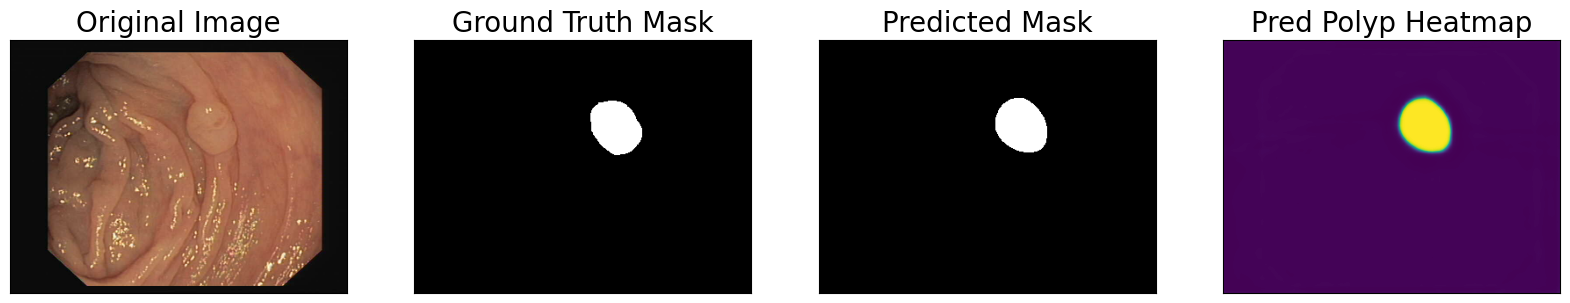

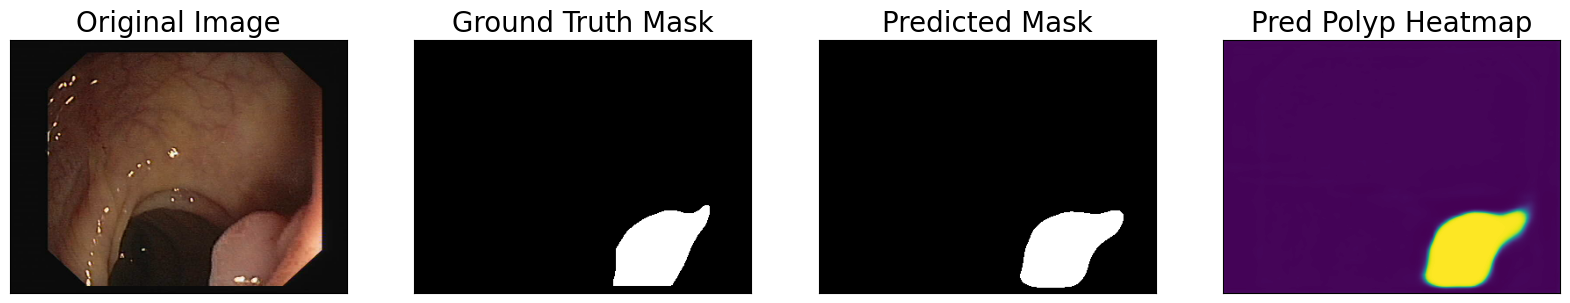

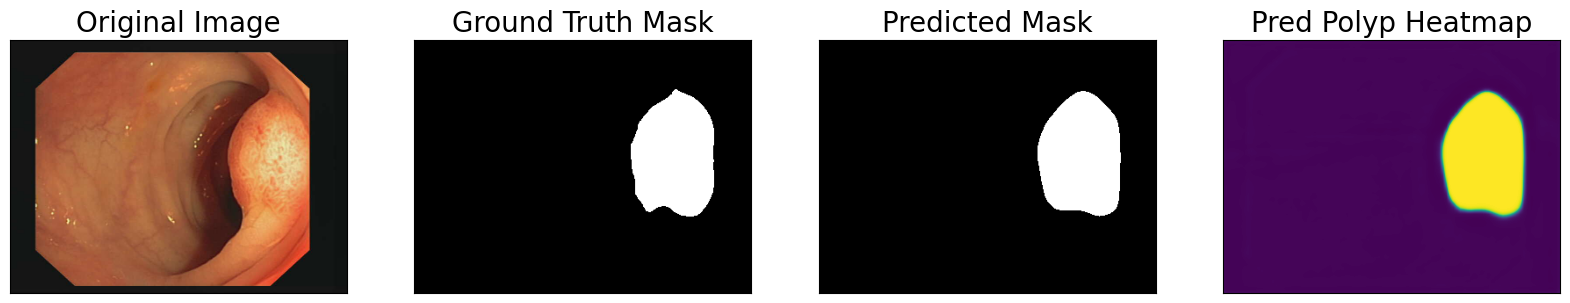

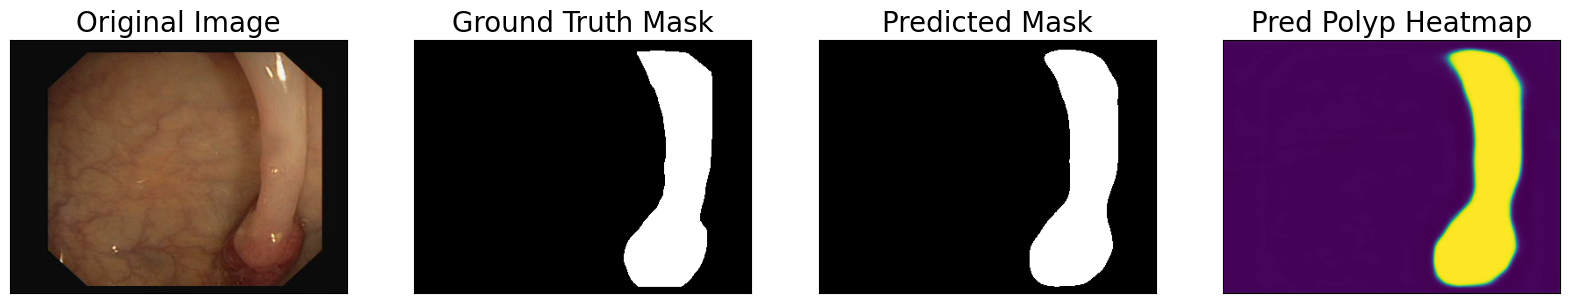

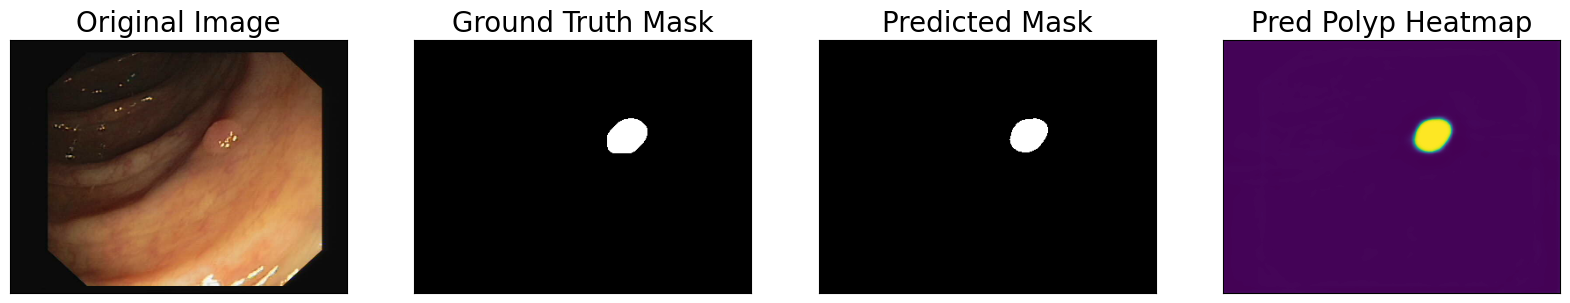

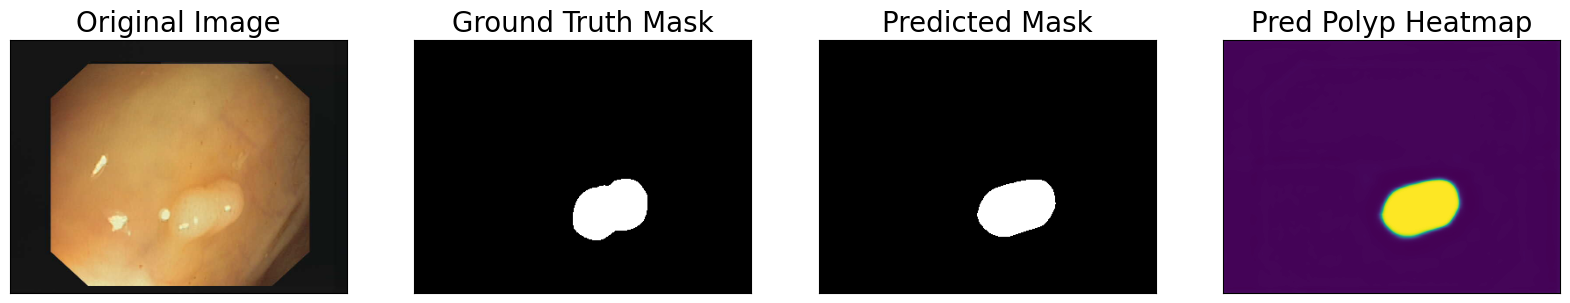

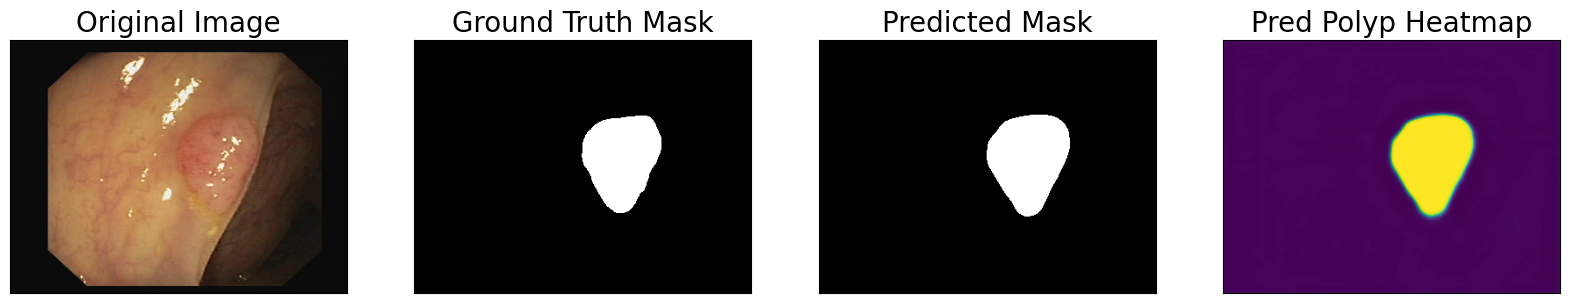

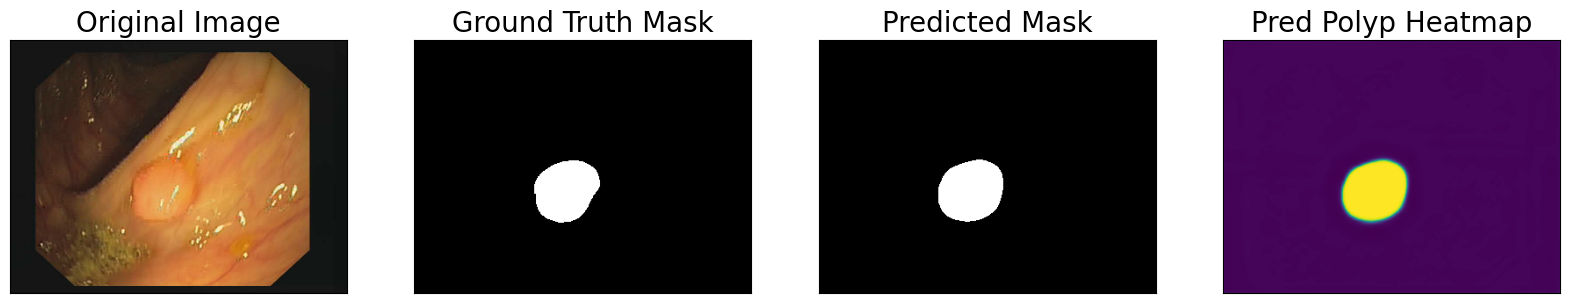

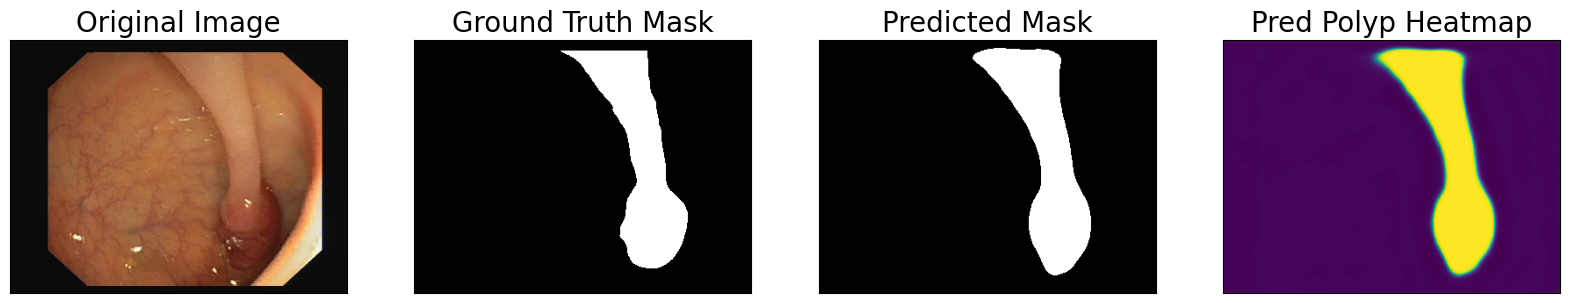

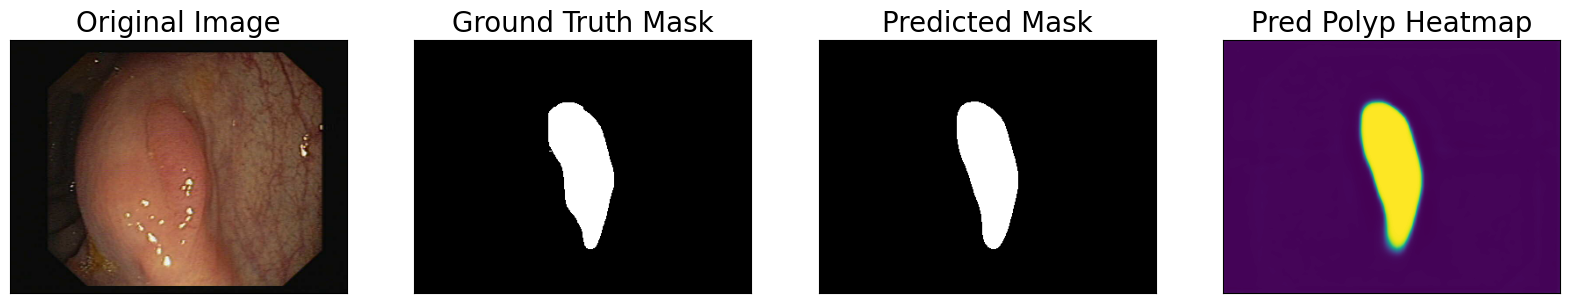

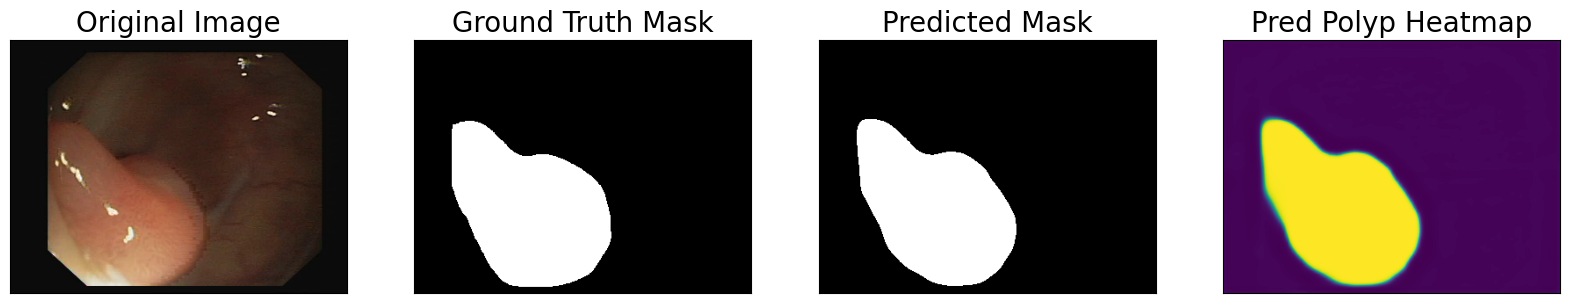

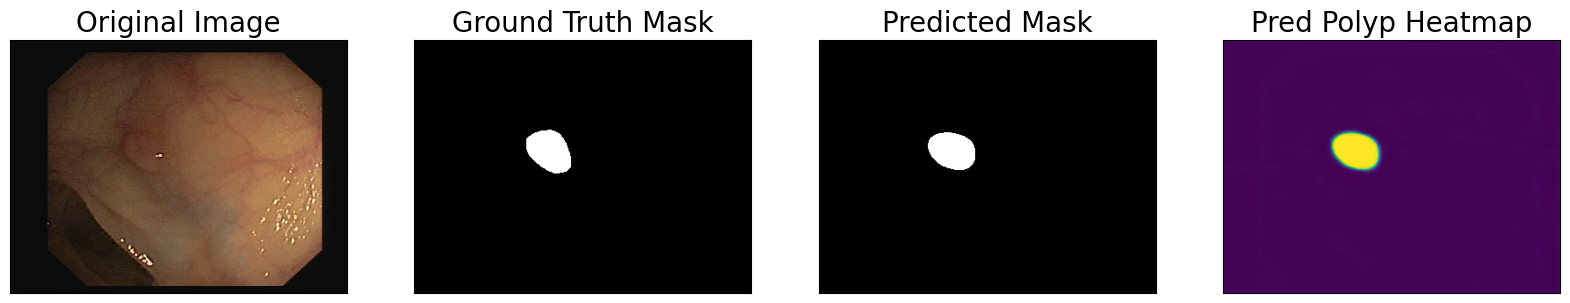

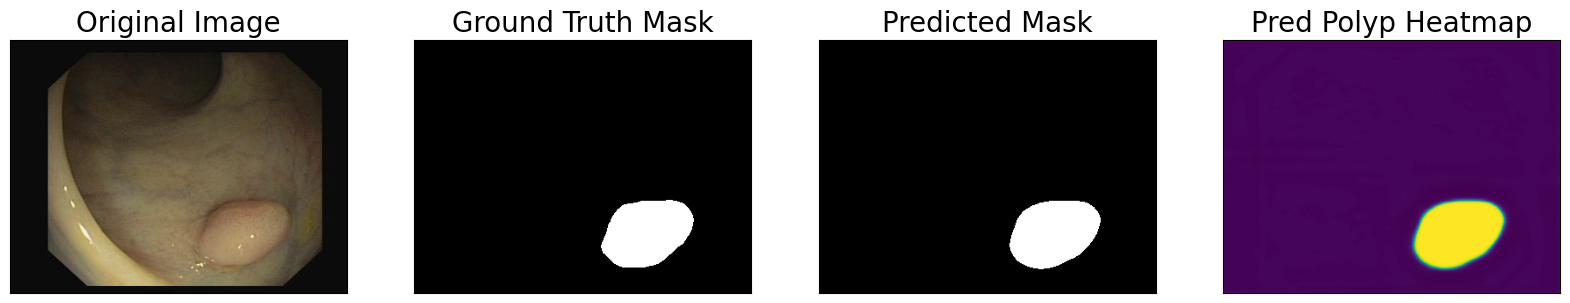

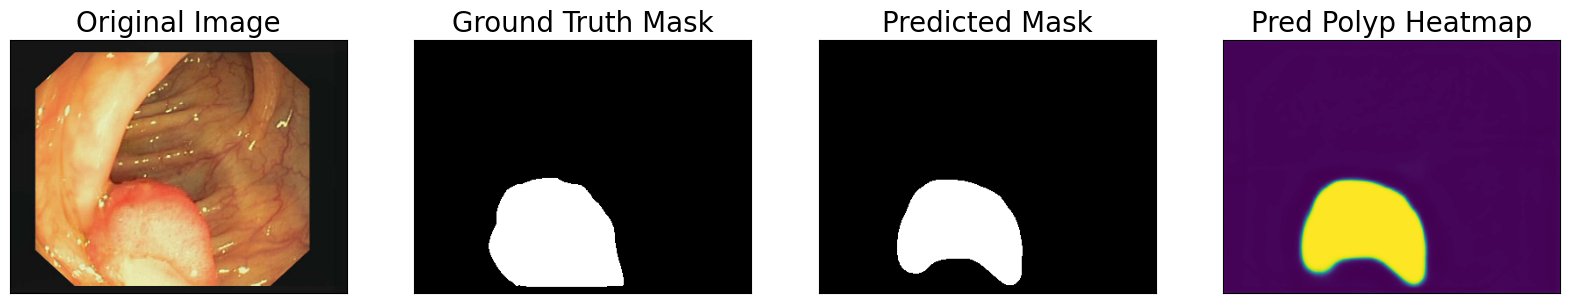

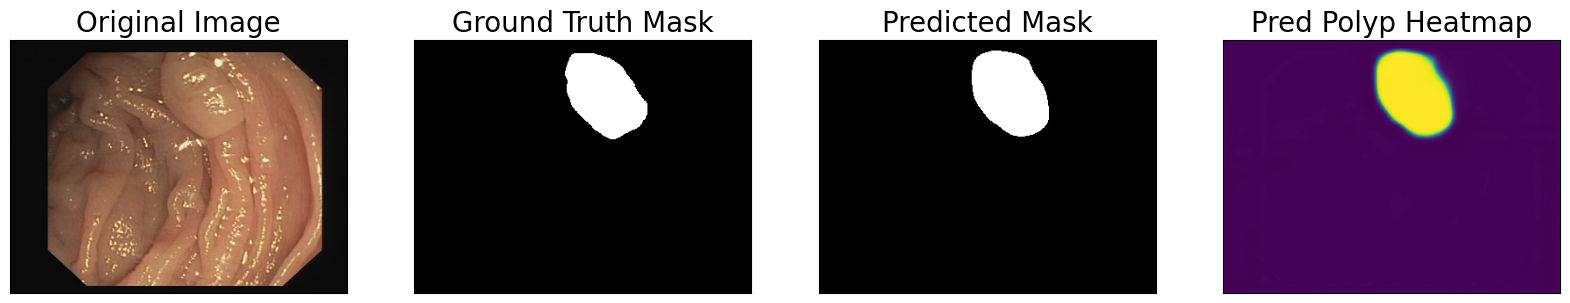

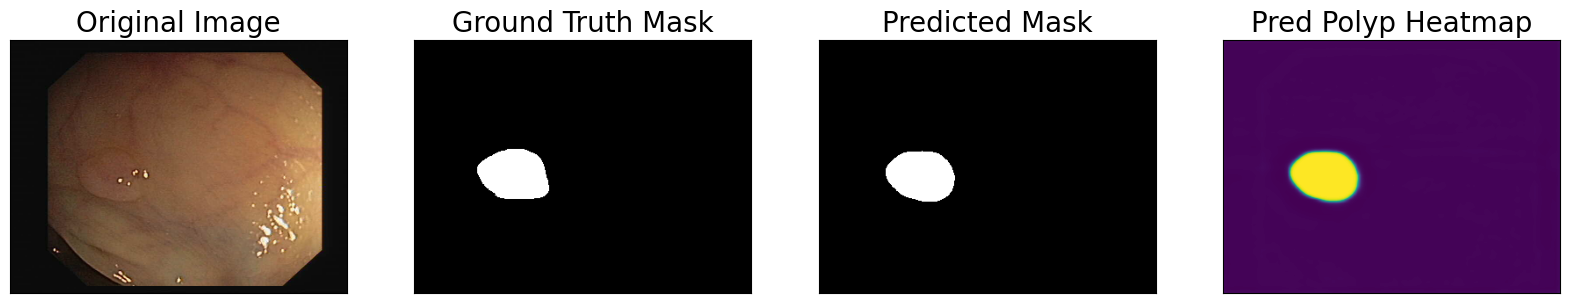

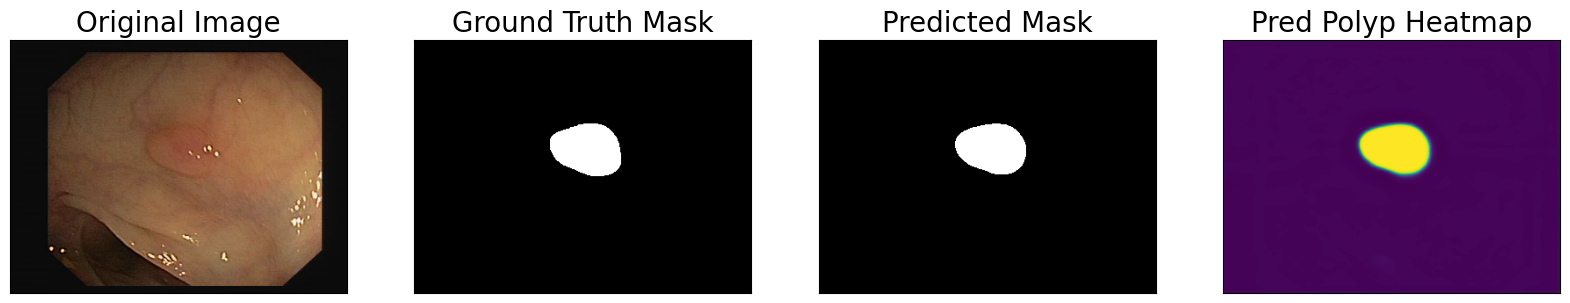

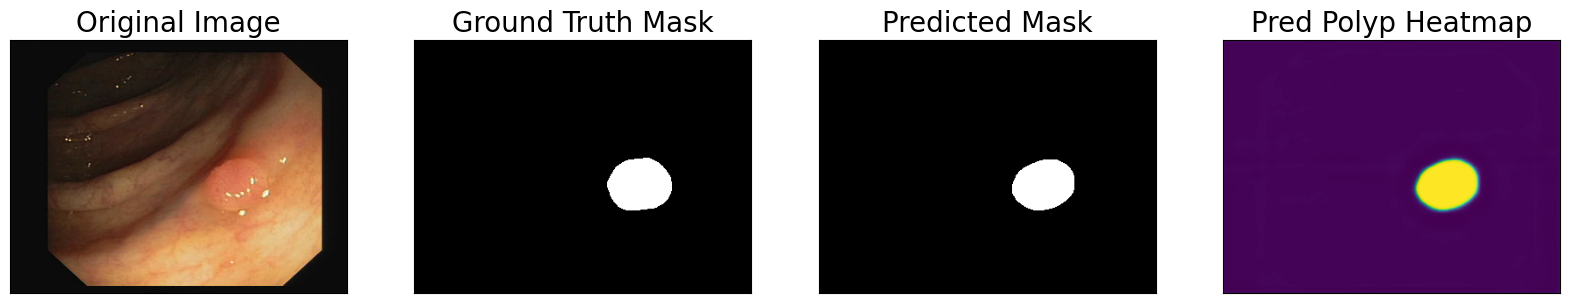

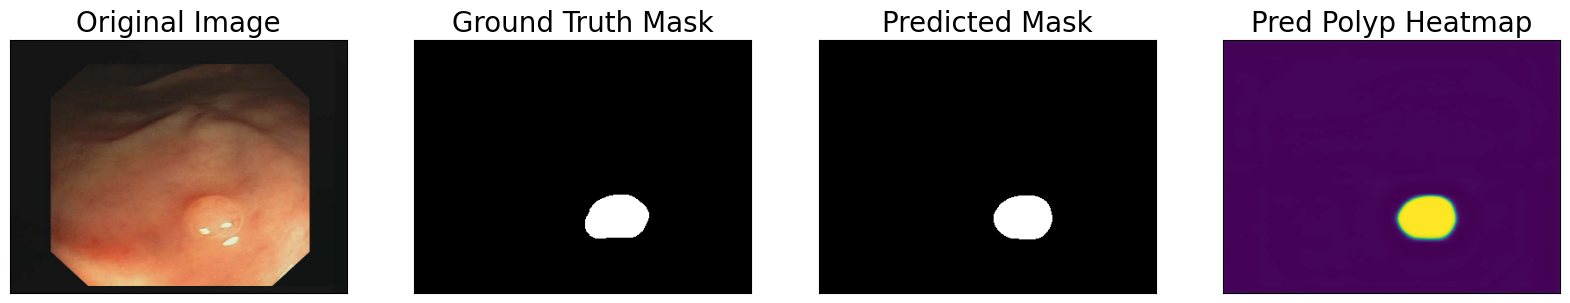

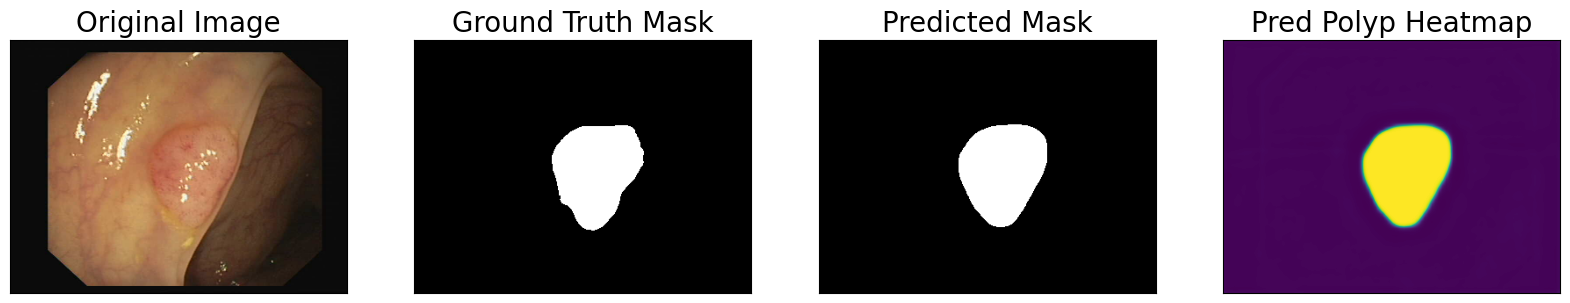

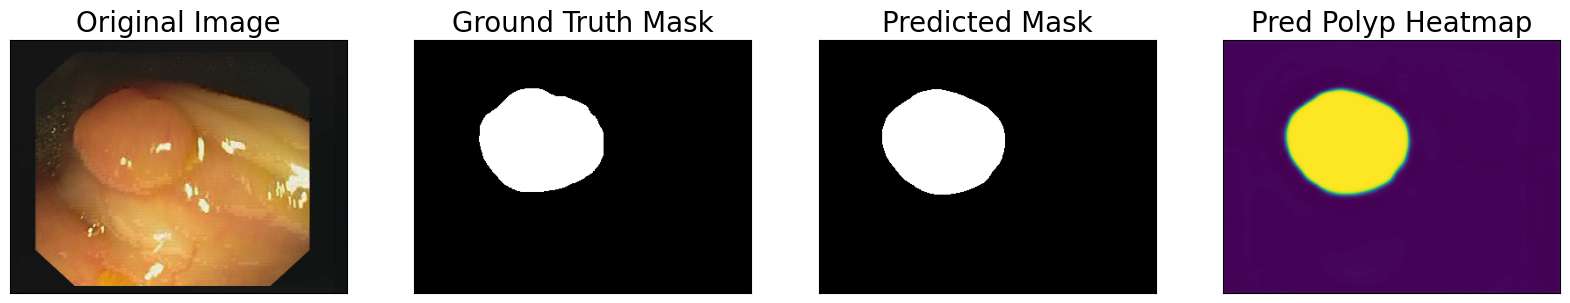

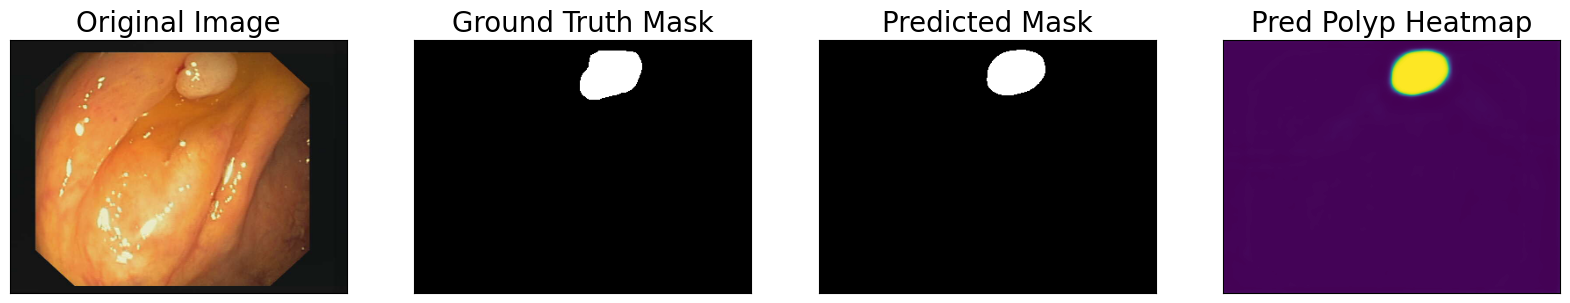

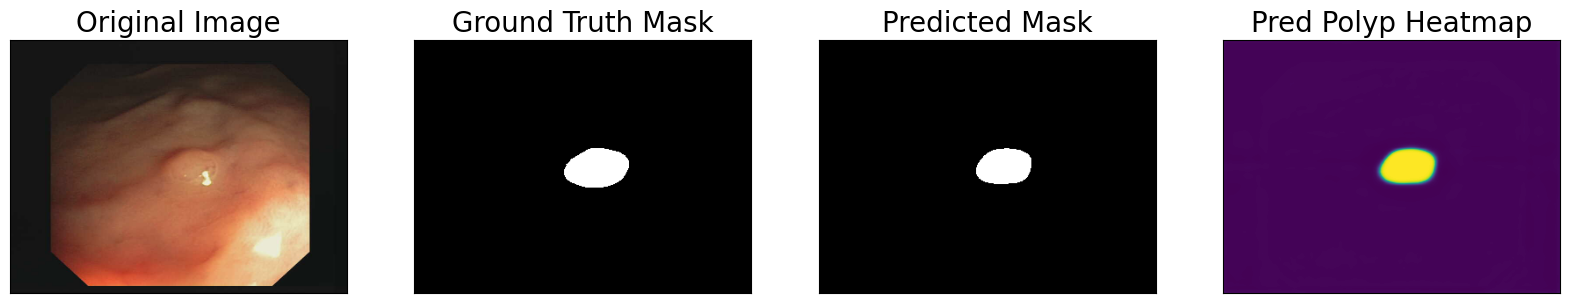

In [36]:
for idx in range(len(test_dataset)):

    image, gt_mask = test_dataset[idx]
    image_vis = test_dataset_vis[idx][0].astype('uint8')
    true_dimensions = image_vis.shape
    x_tensor = torch.from_numpy(image).to(DEVICE).unsqueeze(0)
    # Predict test image
    pred_mask = best_model(x_tensor)
    pred_mask = pred_mask.detach().squeeze().cpu().numpy()
    # Convert pred_mask from `CHW` format to `HWC` format
    pred_mask = np.transpose(pred_mask,(1,2,0))
    # Get prediction channel corresponding to foreground
    pred_polyp_heatmap = crop_image(pred_mask[:,:,select_classes.index('polyp')], true_dimensions)['image']
    pred_mask = crop_image(colour_code_segmentation(reverse_one_hot(pred_mask), select_class_rgb_values), true_dimensions)['image']
    # Convert gt_mask from `CHW` format to `HWC` format
    gt_mask = np.transpose(gt_mask,(1,2,0))
    gt_mask = crop_image(colour_code_segmentation(reverse_one_hot(gt_mask), select_class_rgb_values), true_dimensions)['image']
    cv2.imwrite(os.path.join(sample_preds_folder, f"sample_pred_{idx}.png"), np.hstack([image_vis, gt_mask, pred_mask])[:,:,::-1])
    
    visualize(
        original_image = image_vis,
        ground_truth_mask = gt_mask,
        predicted_mask = pred_mask,
        pred_polyp_heatmap = pred_polyp_heatmap
    )

In [37]:
test_epoch = smp.utils.train.ValidEpoch(
    model,
    loss=loss, 
    metrics=metrics, 
    device=DEVICE,
    verbose=True,
)

valid_logs = test_epoch.run(test_dataloader)
print("Evaluation on Test Data: ")
print(f"Mean IoU Score: {valid_logs['iou_score']:.4f}")
print(f"Mean Dice Loss: {valid_logs['dice_loss']:.4f}")

valid: 100%|██████████| 41/41 [00:07<00:00,  5.16it/s, dice_loss - 0.02254, iou_score - 0.9826]
Evaluation on Test Data: 
Mean IoU Score: 0.9826
Mean Dice Loss: 0.0225
valid: 100%|██████████| 41/41 [00:07<00:00,  5.16it/s, dice_loss - 0.02254, iou_score - 0.9826]
Evaluation on Test Data: 
Mean IoU Score: 0.9826
Mean Dice Loss: 0.0225


In [38]:
train_logs_df = pd.DataFrame(train_logs_list)
valid_logs_df = pd.DataFrame(valid_logs_list)
train_logs_df.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
dice_loss,0.240602,0.174006,0.137085,0.113408,0.096673,0.081592,0.071038,0.062111,0.055163,0.050292,0.048419,0.043194,0.037753,0.034439,0.031575,0.029275,0.026927,0.025012,0.023487,0.022065
iou_score,0.884778,0.936177,0.954459,0.962283,0.964660,0.972989,0.974818,0.977611,0.978043,0.977769,0.972628,0.975534,0.980529,0.981730,0.983084,0.983649,0.985059,0.986075,0.986371,0.986919


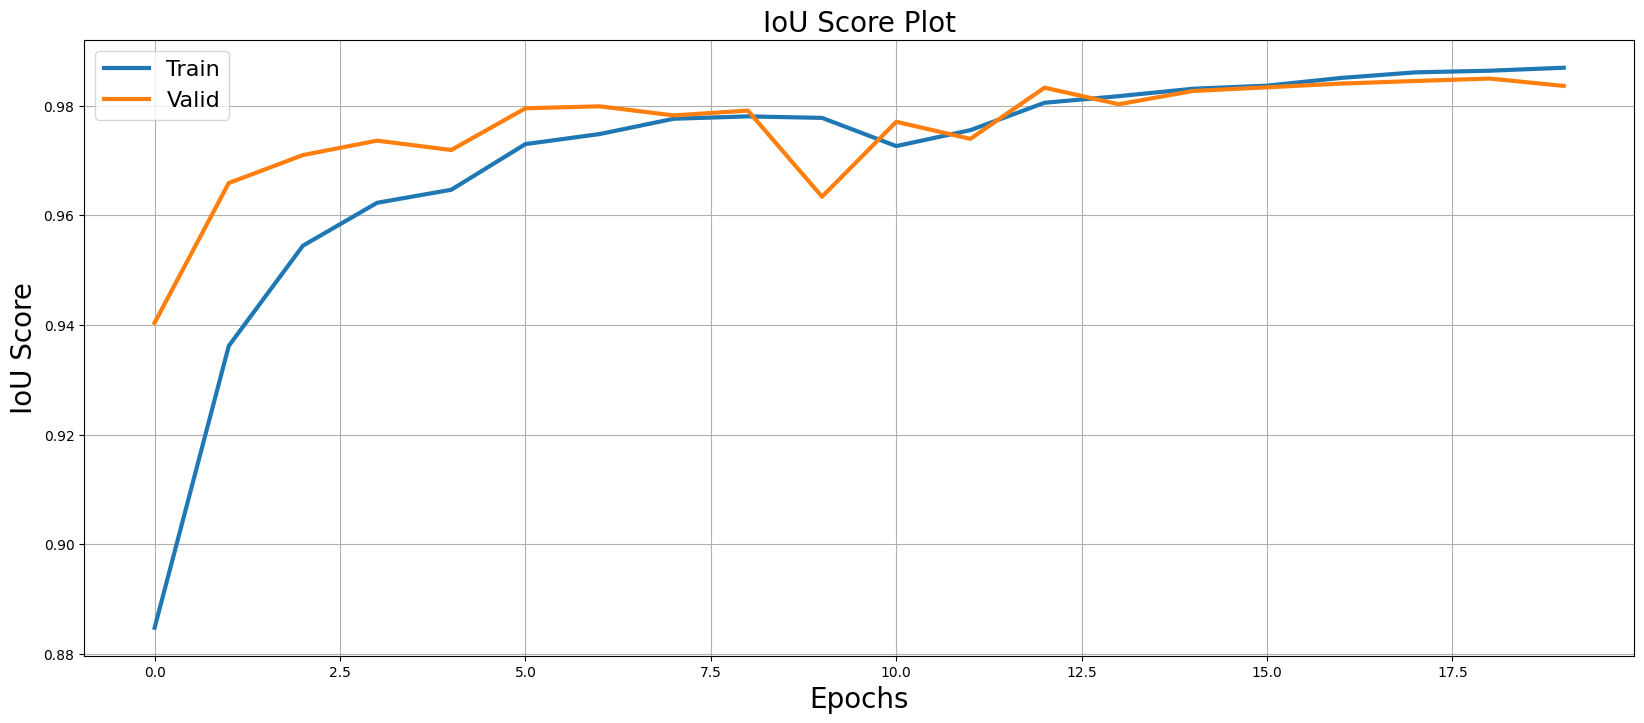

In [39]:
plt.figure(figsize=(20,8))
plt.plot(train_logs_df.index.tolist(), train_logs_df.iou_score.tolist(), lw=3, label = 'Train')
plt.plot(valid_logs_df.index.tolist(), valid_logs_df.iou_score.tolist(), lw=3, label = 'Valid')
plt.xlabel('Epochs', fontsize=20)
plt.ylabel('IoU Score', fontsize=20)
plt.title('IoU Score Plot', fontsize=20)
plt.legend(loc='best', fontsize=16)
plt.grid()
plt.savefig('iou_score_plot.png')
plt.show()

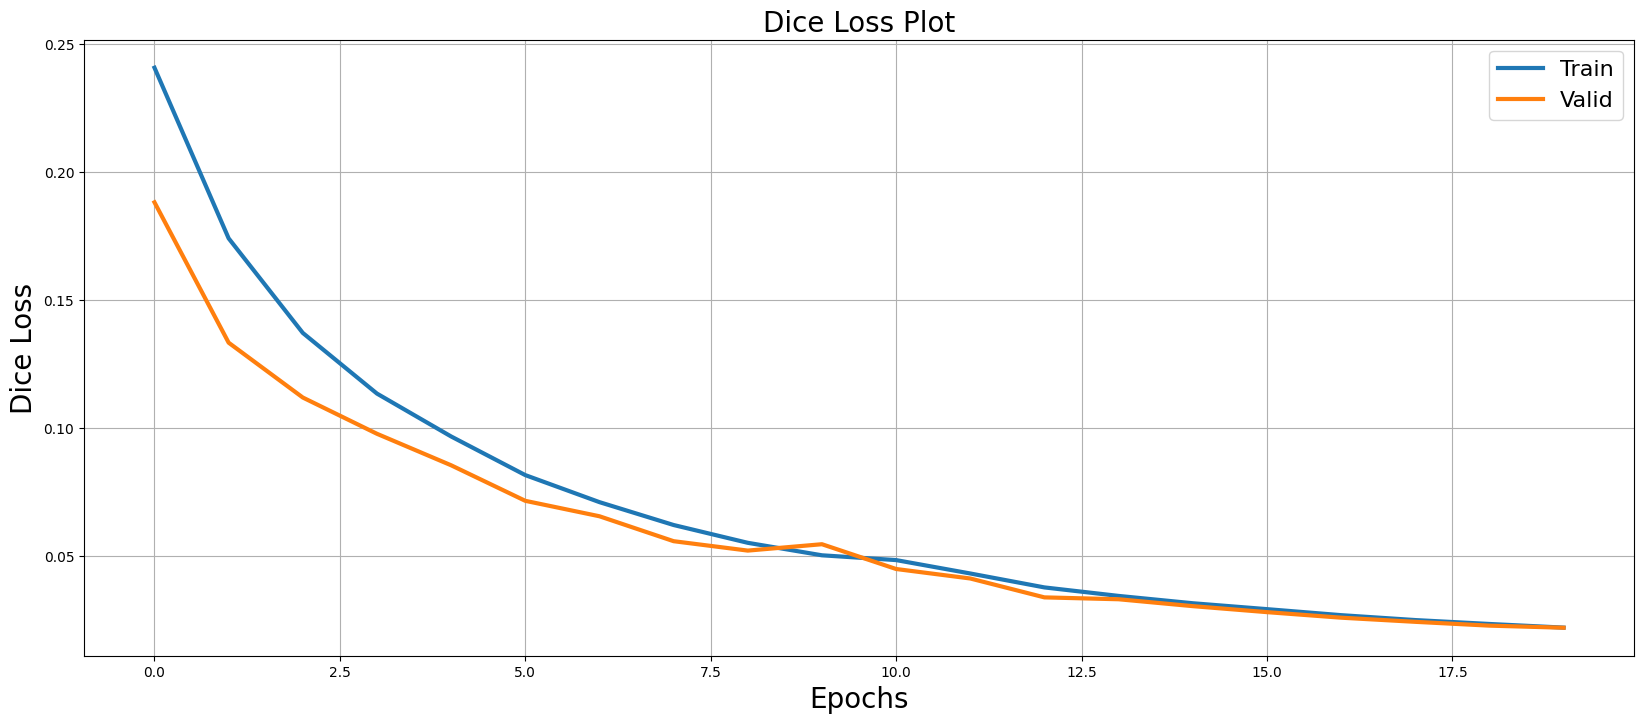

In [40]:
plt.figure(figsize=(20,8))
plt.plot(train_logs_df.index.tolist(), train_logs_df.dice_loss.tolist(), lw=3, label = 'Train')
plt.plot(valid_logs_df.index.tolist(), valid_logs_df.dice_loss.tolist(), lw=3, label = 'Valid')
plt.xlabel('Epochs', fontsize=20)
plt.ylabel('Dice Loss', fontsize=20)
plt.title('Dice Loss Plot', fontsize=20)
plt.legend(loc='best', fontsize=16)
plt.grid()
plt.savefig('dice_loss_plot.png')
plt.show()